# 04 - Baseline and Fighting Class Imbalance
Goal: establish the TinyNet baseline, then fight the class imbalance with weighted CrossEntropyLoss,
and measure whether rare-class recall (especially melanoma) improves. Before/after comparison.

In [1]:
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

train_data = DermaMNIST(split="train", download=True, size=28, transform=transform)
val_data   = DermaMNIST(split="val",   download=True, size=28, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=64, shuffle=False)

class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2352, 128)
        self.fc2 = nn.Linear(128, 7)
    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

print("setup ready")

setup ready


## Weighted loss: the idea
The model ignored rare classes because they barely moved the loss (class 5 dominates at 67%).
Weighted CrossEntropyLoss assigns each class a weight = errors on high-weight classes cost more.
- Use inverse frequency: weight = 1 / class_count -> rare classes get LARGE weights, common get small.
- Forces the model to stop ignoring rare classes (like melanoma).
Analogy: a teacher making rare exam topics worth more points, so a lazy student can't skip them.

In [2]:
import numpy as np

labels_all = train_data.labels.flatten()
classes, counts = np.unique(labels_all, return_counts=True)

# inverse frequency: rare class -> large weight
weights = 1.0 / counts
weights = weights / weights.sum() * len(classes)   # normalise so weights average ~1

class_weights = torch.tensor(weights, dtype=torch.float32)

for c, n, w in zip(classes, counts, weights):
    print(f"class {c}: {n:5d} images  ->  weight {w:.2f}")

print("\nweights tensor:", class_weights)

class 0:   228 images  ->  weight 0.94
class 1:   359 images  ->  weight 0.60
class 2:   769 images  ->  weight 0.28
class 3:    80 images  ->  weight 2.69
class 4:   779 images  ->  weight 0.28
class 5:  4693 images  ->  weight 0.05
class 6:    99 images  ->  weight 2.17

weights tensor: tensor([0.9426, 0.5987, 0.2795, 2.6865, 0.2759, 0.0458, 2.1709])


In [3]:
model = TinyNet()                                              # fresh model
criterion = nn.CrossEntropyLoss(weight=class_weights)          # <-- the only change: weighted loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        labels = labels.squeeze()
        logits = model(images)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"epoch {epoch:2d}  train loss {running_loss/len(train_loader):.4f}")

epoch  0  train loss 1.7665
epoch  1  train loss 1.6239
epoch  2  train loss 1.5552
epoch  3  train loss 1.4620
epoch  4  train loss 1.4423
epoch  5  train loss 1.4055
epoch  6  train loss 1.3619
epoch  7  train loss 1.3230
epoch  8  train loss 1.2739
epoch  9  train loss 1.2625


## Training with weighted loss
Only change from baseline: `nn.CrossEntropyLoss(weight=class_weights)`.
Train loss went UP vs baseline (1.77 -> 1.26 here, vs baseline 1.00 -> 0.72), and that is expected:
rare-class mistakes now cost more, so the loss finally counts the failures it used to ignore.
Higher loss here does NOT mean worse - it means the loss measures what we care about.
Real test is per-class recall on validation, next.

In [4]:
model.eval()
correct = total = 0
per_class_correct = [0]*7
per_class_total = [0]*7

with torch.no_grad():
    for images, labels in val_loader:
        labels = labels.squeeze()
        preds = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        for c in range(7):
            mask = (labels == c)
            per_class_total[c] += mask.sum().item()
            per_class_correct[c] += (preds[mask] == c).sum().item()

print(f"overall val accuracy: {100*correct/total:.1f}%\n")
for c in range(7):
    recall = 100*per_class_correct[c]/per_class_total[c] if per_class_total[c] else 0
    print(f"class {c}: {per_class_correct[c]:3d}/{per_class_total[c]:3d}  ({recall:4.1f}% recall)")

overall val accuracy: 48.2%

class 0:  14/ 33  (42.4% recall)
class 1:  30/ 52  (57.7% recall)
class 2:  46/110  (41.8% recall)
class 3:   3/ 12  (25.0% recall)
class 4:  42/111  (37.8% recall)
class 5: 338/671  (50.4% recall)
class 6:  10/ 14  (71.4% recall)


## Weighted results vs baseline

| Class | Baseline recall | Weighted recall |
|---|---|---|
| 0 (actinic keratoses) | 15.2% | 42.4% |
| 1 (basal cell carcinoma) | 55.8% | 57.7% |
| 2 (benign keratosis) | 26.4% | 41.8% |
| 3 (dermatofibroma) | 0.0% | 25.0% |
| 4 (melanoma) | 18.9% | 37.8% |
| 5 (melanocytic nevi, majority) | 94.6% | 50.4% |
| 6 (vascular lesions) | 21.4% | 71.4% |
| **overall accuracy** | **72.0%** | **48.2%** |

The majority class (5) dropped ~44 points; all six rarer classes improved, some hugely (class 6: 21% -> 71%, melanoma doubled, class 3 escaped 0%).
Overall accuracy fell (72% -> 48%), but this is the model getting MORE useful, not worse: the 72% was inflated by the majority class alone.
Trading easy majority-class wins for catching melanoma and rare lesions is the right call for a screening tool.

Key lesson: a lower headline number can mean a better model. Per-class recall reveals what accuracy hides.

In [5]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ["actinic\nkeratoses", "basal cell\ncarcinoma", "benign\nkeratosis",
               "dermato-\nfibroma", "melanoma", "nevi\n(majority)", "vascular"]

baseline_recall = [15.2, 55.8, 26.4,  0.0, 18.9, 94.6, 21.4]
weighted_recall = [42.4, 57.7, 41.8, 25.0, 37.8, 50.4, 71.4]

print("data ready to plot")

data ready to plot


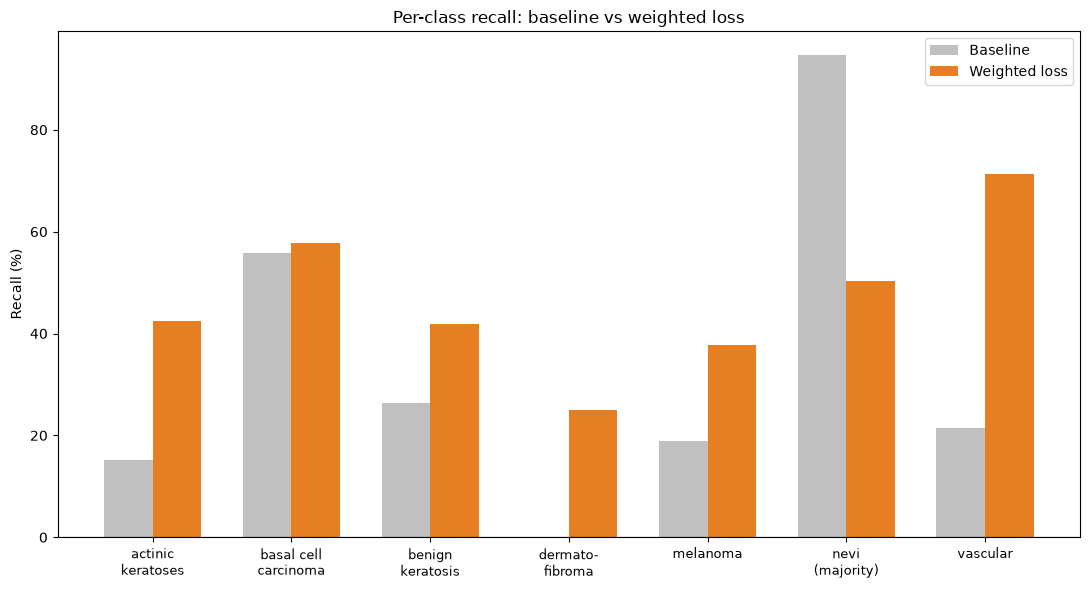

In [6]:
x = np.arange(len(class_names))   # positions 0,1,2,...,6 - one slot per class
width = 0.35                       # width of each bar

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2, baseline_recall, width, label="Baseline", color="#c0c0c0")
bars2 = ax.bar(x + width/2, weighted_recall, width, label="Weighted loss", color="#e67e22")

ax.set_ylabel("Recall (%)")
ax.set_title("Per-class recall: baseline vs weighted loss")
ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=9)
ax.legend()
ax.axhline(y=0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("recall_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Reading the chart
Weighted loss (orange) beats baseline (grey) on every class except nevi (the majority).
- Nevi: the lone tall grey bar (~95%) = the baseline over-investing in the majority class, which inflated its accuracy.
- Dermatofibroma: baseline has NO bar (0% recall); weighting lifts it to 25%.
- One image = the whole thesis: weighting sacrifices some majority-class performance to rescue every rare class.
This is the hero figure for the README.